In [1]:
%pip install -q timm transformers albumentations datasets accelerate processor supervision torchmetrics onnxscript onnx onnxruntime numpy Pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.4/113.4 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.0/127.0 kB 6.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


Loading INT8 with providers: ['AzureExecutionProvider', 'CPUExecutionProvider']
Loading PRUNED with providers: ['AzureExecutionProvider', 'CPUExecutionProvider']
Loading ORIGINAL with providers: ['AzureExecutionProvider', 'CPUExecutionProvider']
Found 293 test images

Preprocessing 200 images for throughput test...

--- Throughput Measurement (batch_size=1) ---
INT8       -> 0.48 FPS, 2084.99 ms per image
PRUNED     -> 1.62 FPS, 616.96 ms per image
ORIGINAL   -> 1.59 FPS, 628.82 ms per image


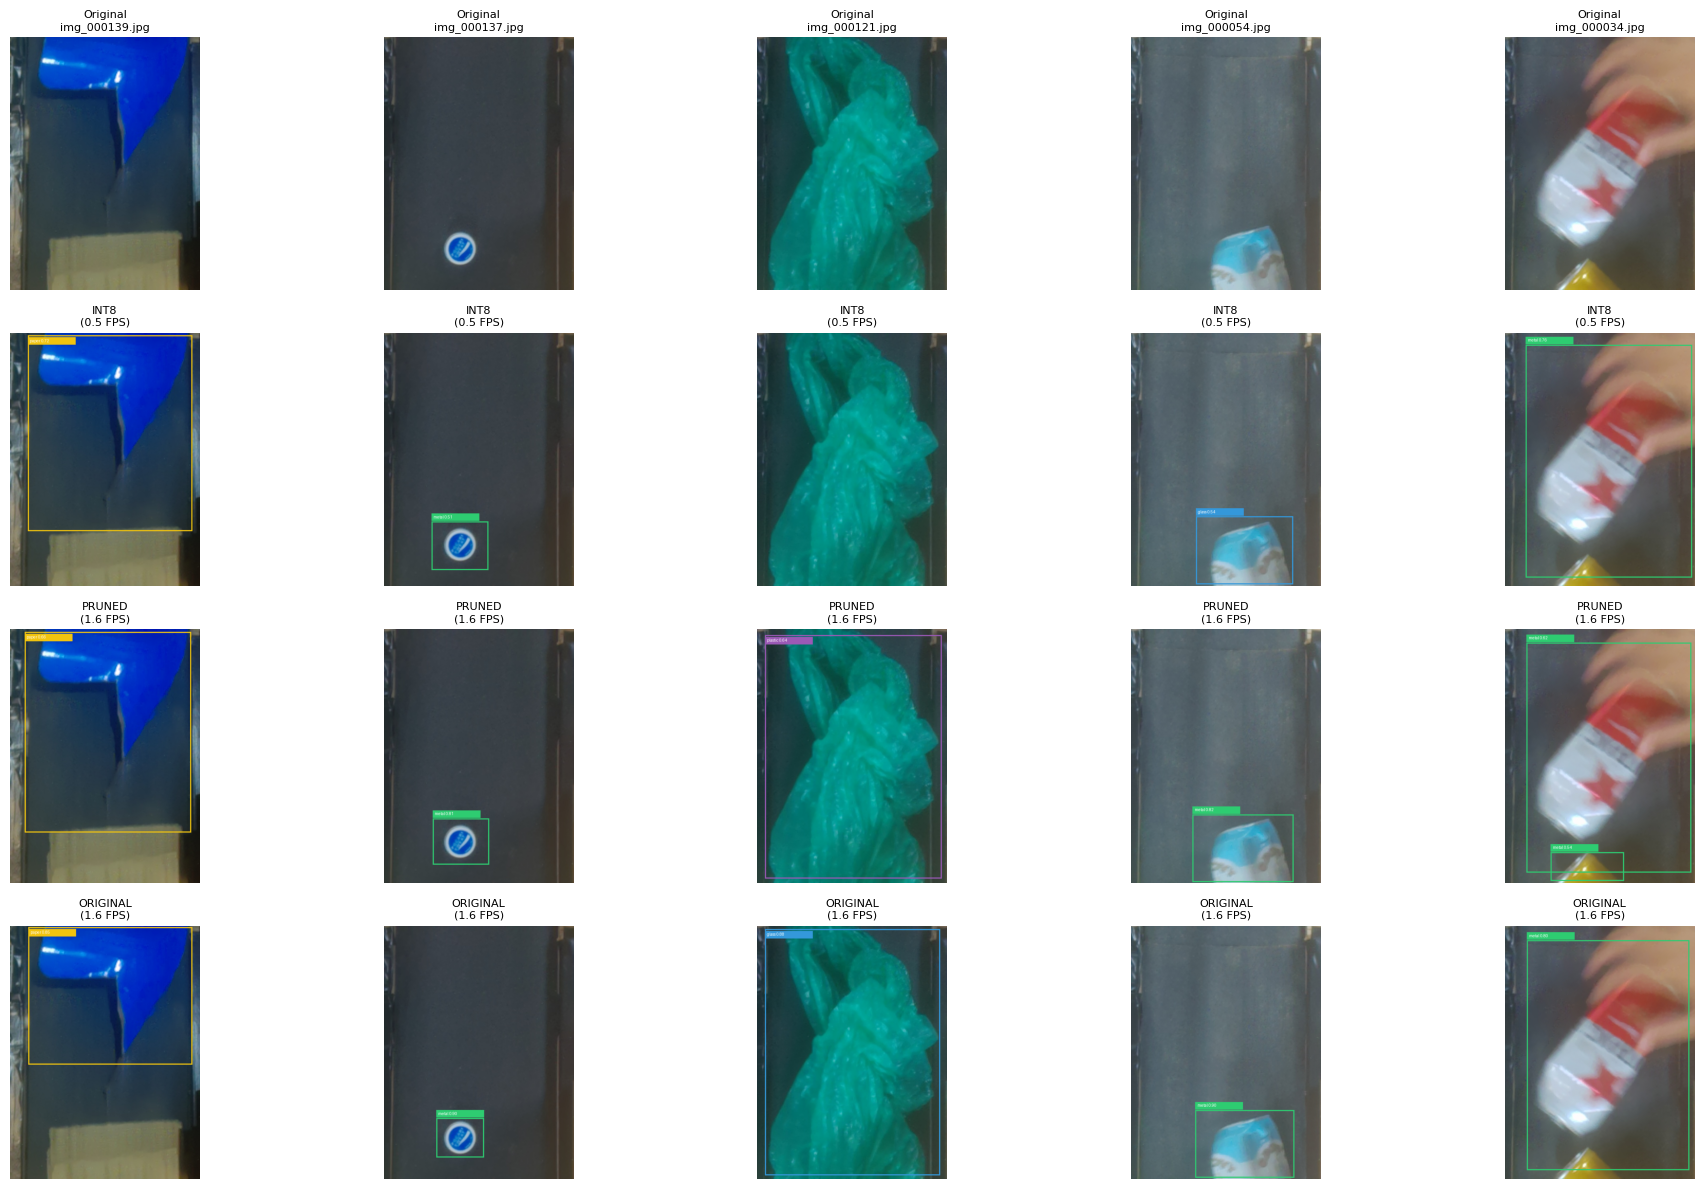


--- Throughput Summary ---
INT8      :   0.48 FPS  (2084.99 ms/image)
PRUNED    :   1.62 FPS  (616.96 ms/image)
ORIGINAL  :   1.59 FPS  (628.82 ms/image)


In [2]:
import os
import glob
import random
import time
import numpy as np
import torch
import onnxruntime as ort
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Define your ONNX models
# ------------------------------------------------------------
quantized_models = {
    "INT8": "/kaggle/input/notebooks/sumn2u/conveyor-belt-conversions/rtdetr_pruned_finetuned_int8.onnx",
    "PRUNED": "/kaggle/input/notebooks/sumn2u/conveyor-belt-conversions/rtdetr_pruned.onnx",
    "ORIGINAL": "/kaggle/input/notebooks/sumn2u/conveyor-belt-conversions/rtdetr.onnx",
}

# ------------------------------------------------------------
# 2. Load ONNX sessions with optimisations
# ------------------------------------------------------------
sessions = {}
for name, path in quantized_models.items():
    if not os.path.exists(path):
        print(f"Warning: {path} not found – skipping {name}")
        continue
    
    opts = ort.SessionOptions()
    opts.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    opts.intra_op_num_threads = 2
    opts.inter_op_num_threads = 2
    
    available = ort.get_available_providers()
    preferred_order = ['AzureExecutionProvider', 'CPUExecutionProvider']
    providers = [p for p in preferred_order if p in available]
    
    print(f"Loading {name} with providers: {providers}")
    sess = ort.InferenceSession(path, opts, providers=providers)
    sessions[name] = sess

# ------------------------------------------------------------
# 3. Locate dataset images (inside class/images/)
# ------------------------------------------------------------
dataset_root = "/kaggle/input/datasets/sumn2u/conveyor-belt-recyclables-dataset"
classes = ["cardboard", "glass", "metal", "paper", "plastic"]
id2label = {i: cls for i, cls in enumerate(classes)}
colors = [(231,76,60), (52,152,219), (46,204,113), (241,196,15), (155,89,182)]

test_images = []
for cls in classes:
    images_dir = os.path.join(dataset_root, cls, "images")
    if not os.path.isdir(images_dir):
        print(f"Warning: {images_dir} does not exist – skipping {cls}")
        continue
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        test_images.extend(glob.glob(os.path.join(images_dir, ext)))

print(f"Found {len(test_images)} test images")
if not test_images:
    raise FileNotFoundError("No images found. Expected: dataset_root/class_name/images/*.jpg")

# ------------------------------------------------------------
# 4. Inference & drawing functions
# ------------------------------------------------------------
def preprocess_image_to_numpy(image):
    """Returns numpy array (1,3,640,640) ready for model."""
    input_img = image.resize((640, 640))
    img_data = np.array(input_img).astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img_data = (img_data - mean) / std
    img_data = np.transpose(img_data, (2, 0, 1))
    img_data = np.expand_dims(img_data, axis=0).astype(np.float32)
    return img_data

def predict_onnx(session, image, threshold=0.5):
    """Run inference and return scores, labels, boxes (absolute xyxy)."""
    img_data = preprocess_image_to_numpy(image)
    logits, boxes_norm = session.run(None, {"pixel_values": img_data})
    logits = torch.tensor(logits[0])
    boxes_norm = torch.tensor(boxes_norm[0])
    orig_w, orig_h = image.size

    probs = torch.sigmoid(logits)
    scores, labels = probs.max(dim=-1)
    keep = scores > threshold

    cx = boxes_norm[:, 0] * orig_w
    cy = boxes_norm[:, 1] * orig_h
    bw = boxes_norm[:, 2] * orig_w
    bh = boxes_norm[:, 3] * orig_h
    x1 = (cx - bw/2).clamp(0, orig_w)
    y1 = (cy - bh/2).clamp(0, orig_h)
    x2 = (cx + bw/2).clamp(0, orig_w)
    y2 = (cy + bh/2).clamp(0, orig_h)
    boxes_abs = torch.stack([x1, y1, x2, y2], dim=1)

    return scores[keep].numpy(), labels[keep].numpy(), boxes_abs[keep].numpy()

def draw_boxes(image, scores, labels, boxes, threshold=0.4):
    draw = ImageDraw.Draw(image)
    for score, label, box in zip(scores, labels, boxes):
        if score < threshold:
            continue
        x1, y1, x2, y2 = box
        color = colors[label % len(colors)]
        label_name = id2label[label]
        text = f"{label_name} {score:.2f}"
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
        text_y = y1 - 20 if y1 > 20 else y1 + 5
        draw.rectangle([x1, text_y, x1 + 120, text_y + 18], fill=color)
        draw.text((x1 + 5, text_y + 2), text, fill="white")
    return image

# ------------------------------------------------------------
# 5. Throughput measurement (batched)
# ------------------------------------------------------------
def measure_throughput_batched(session, preprocessed_images, batch_size=1, num_warmup=10):
    n = len(preprocessed_images)
    batches = [np.concatenate(preprocessed_images[i:i+batch_size], axis=0) 
               for i in range(0, n, batch_size)]
    # warmup
    for _ in range(num_warmup):
        _ = session.run(None, {"pixel_values": batches[0]})
    total_images = 0
    start = time.perf_counter()
    for batch in batches:
        _ = session.run(None, {"pixel_values": batch})
        total_images += batch.shape[0]
    end = time.perf_counter()
    elapsed = end - start
    fps = total_images / elapsed
    ms_per_img = (elapsed / total_images) * 1000
    return fps, ms_per_img

# Use a subset of images for timing
num_test_images = min(200, len(test_images))
timing_images = random.sample(test_images, num_test_images)
print(f"\nPreprocessing {len(timing_images)} images for throughput test...")
preprocessed_timing = [preprocess_image_to_numpy(Image.open(p).convert("RGB")) for p in timing_images]

print("\n--- Throughput Measurement (batch_size=1) ---")
throughput_results = {}
for name, sess in sessions.items():
    fps, ms = measure_throughput_batched(sess, preprocessed_timing, batch_size=1)
    throughput_results[name] = (fps, ms)
    print(f"{name:10s} -> {fps:.2f} FPS, {ms:.2f} ms per image")

# (Optional) test batch_size=4
# print("\n--- Throughput Measurement (batch_size=4) ---")
# for name, sess in sessions.items():
#     fps, ms = measure_throughput_batched(sess, preprocessed_timing, batch_size=4)
#     print(f"{name:10s} -> {fps:.2f} FPS, {ms:.2f} ms per image (batch=4)")

# ------------------------------------------------------------
# 6. Run inference on a random sample and display results
# ------------------------------------------------------------
num_to_show = min(5, len(test_images))
sample_images = random.sample(test_images, num_to_show)

fig, axes = plt.subplots(len(sessions) + 1, num_to_show, figsize=(20, 12))

if len(sessions) + 1 == 1:
    axes = np.expand_dims(axes, axis=0)
if num_to_show == 1:
    axes = np.expand_dims(axes, axis=1)

for col, img_path in enumerate(sample_images):
    original_img = Image.open(img_path).convert("RGB")
    axes[0, col].imshow(original_img)
    axes[0, col].axis('off')
    axes[0, col].set_title(f"Original\n{os.path.basename(img_path)}", fontsize=8)

    for row, (name, sess) in enumerate(sessions.items(), start=1):
        img_copy = original_img.copy()
        scores, labels, boxes = predict_onnx(sess, original_img)
        draw_boxes(img_copy, scores, labels, boxes)
        axes[row, col].imshow(img_copy)
        axes[row, col].axis('off')
        fps, _ = throughput_results.get(name, (0,0))
        axes[row, col].set_title(f"{name}\n({fps:.1f} FPS)", fontsize=8)

plt.tight_layout()
plt.show()

# Print summary
print("\n--- Throughput Summary ---")
for name, (fps, avg_ms) in throughput_results.items():
    print(f"{name:10s}: {fps:6.2f} FPS  ({avg_ms:6.2f} ms/image)")

In [3]:
import onnxruntime as ort

# ------------------------------------------------------------
# 2. Load ONNX sessions with optimisations
# ------------------------------------------------------------
sessions = {}
for name, path in quantized_models.items():
    if not os.path.exists(path):
        print(f"Warning: {path} not found – skipping {name}")
        continue
    
    # Enable all graph optimisations
    opts = ort.SessionOptions()
    opts.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    
    # Set number of threads (adjust to your CPU cores, e.g., 2)
    opts.intra_op_num_threads = 2
    opts.inter_op_num_threads = 2
    
    # Use available providers (prioritise Azure if it's faster, else CPU)
    available = ort.get_available_providers()
    # Prefer AzureExecutionProvider (if present) because it might be optimised for the cloud
    preferred_order = ['AzureExecutionProvider', 'CPUExecutionProvider']
    providers = [p for p in preferred_order if p in available]
    
    print(f"Loading {name} with providers: {providers}")
    sess = ort.InferenceSession(path, opts, providers=providers)
    sessions[name] = sess

Loading INT8 with providers: ['AzureExecutionProvider', 'CPUExecutionProvider']
Loading PRUNED with providers: ['AzureExecutionProvider', 'CPUExecutionProvider']
Loading ORIGINAL with providers: ['AzureExecutionProvider', 'CPUExecutionProvider']


In [4]:
print("\n--- Raw Model Speed (dummy input, no preprocessing) ---")
dummy_input = np.random.randn(1, 3, 640, 640).astype(np.float32)
for name, sess in sessions.items():
    # Warmup
    for _ in range(10):
        _ = sess.run(None, {"pixel_values": dummy_input})
    # Time 100 runs
    start = time.perf_counter()
    for _ in range(100):
        _ = sess.run(None, {"pixel_values": dummy_input})
    end = time.perf_counter()
    fps = 100 / (end - start)
    print(f"{name:10s} -> {fps:.2f} FPS (dummy input)")


--- Raw Model Speed (dummy input, no preprocessing) ---
INT8       -> 0.48 FPS (dummy input)
PRUNED     -> 1.64 FPS (dummy input)
ORIGINAL   -> 1.65 FPS (dummy input)
